# Multi-Class Jet Tagging with BDTs

In this tutorial, we revisit the same multi-class jet-tagging problem, this time using a boosted decision tree (BDT). We again train, evaluate, and compare the model step by step using the hls4ml LHC jet dataset from OpenML, which contains about 830,000 simulated jets described by 16 high-level features and labeled as:

- quark (q),
- gluon (g),
- W boson (w),
- Z boson (z),
- top quark (t).

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/nairods/Scies4Free-FastML-tutorial/blob/main/Multi-Class_Classification_BDT.ipynb)

## 1. Import Libraries

In [1]:
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.special import softmax
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
import json
import os
import sys

RANDOM_STATE = 42

## 2. Load Dataset

In [2]:
!rm -rf /content/Scies4Free-FastML-tutorial
!git clone https://github.com/nairods/Scies4Free-FastML-tutorial.git
DATA_PATH = "Scies4Free-FastML-tutorial/data/jet_tagging/"

train = np.load(DATA_PATH + "train.npz", allow_pickle=True)
val   = np.load(DATA_PATH + "val.npz", allow_pickle=True)
test  = np.load(DATA_PATH + "test.npz", allow_pickle=True)

X_train, y_train = train["X"], train["y"]
X_val,   y_val   = val["X"],   val["y"]
X_test,  y_test  = test["X"],  test["y"]

feature_names = ['zlogz', 'c1_b0_mmdt', 'c1_b1_mmdt', 'c1_b2_mmdt', 'c2_b1_mmdt', 'c2_b2_mmdt', 'd2_b1_mmdt', 'd2_b2_mmdt', 'd2_a1_b1_mmdt', 'd2_a1_b2_mmdt', 'm2_b1_mmdt', 'm2_b2_mmdt', 'n2_b1_mmdt', 'n2_b2_mmdt', 'mass_mmdt', 'multiplicity']

Cloning into 'Scies4Free-FastML-tutorial'...
remote: Enumerating objects: 507, done.
remote: Counting objects: 100% (127/127), done.
remote: Compressing objects: 100% (120/120), done.
remote: Total 507 (delta 62), reused 35 (delta 4), pack-reused 380 (from 2)
Receiving objects: 100% (507/507), 100.53 MiB | 17.09 MiB/s, done.
Resolving deltas: 100% (238/238), done.


## 3. Train a BDT
We'll use `xgboost`'s `XGBClassifier` with:

| Parameter | Explanation |
| --- | --- |
| `n_estimators=25` | 25 trees |
| `max_depth=5` | maximum tree depth of 5 |

If you have already trained the model and restarted the notebook kernel, you can set `train = False` to skip training and load the saved model instead.

In [3]:
train = True

if train:
  eval_set = [(X_train, y_train), (X_val, y_val)]


  xgb = XGBClassifier(
      n_estimators=25,
      learning_rate=0.5,
      max_depth=5,
      subsample=0.8,
      colsample_bytree=0.8,
      objective="multi:softprob",    # Output probabilities for multi-class classification
      eval_metric=["mlogloss", "merror"], # Track multi-class loss + classification error during training
      random_state=RANDOM_STATE
  )

  xgb.fit(
      X_train, y_train,
      eval_set=eval_set,
      verbose=False
  )

  evals_base = xgb.evals_result()

  xgb.save_model("/content/Scies4Free-FastML-tutorial/jet_models/bdt/xgb_multiclass.json")

else:
  xgb = XGBClassifier()
  xgb.load_model("/content/Scies4Free-FastML-tutorial/jet_models/bdt/xgb_multiclass.json")
  evals_base = None

### Training History
We plot train vs validation curves for multi-class loss and classification error.

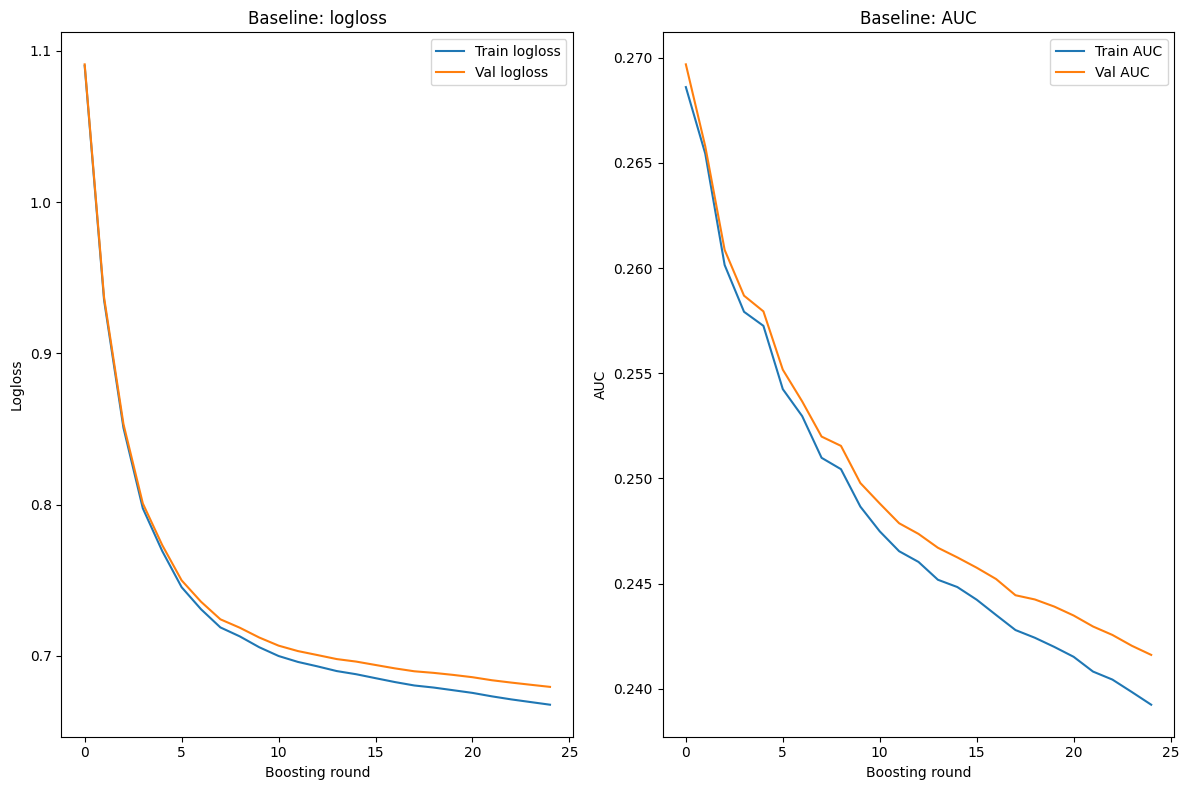

In [4]:
rounds_base = range(len(evals_base["validation_0"]["mlogloss"]))

fig, ax = plt.subplots(1, 2, figsize=(12, 8))

ax[0].plot(rounds_base, evals_base["validation_0"]["mlogloss"], label="Train logloss")
ax[0].plot(rounds_base, evals_base["validation_1"]["mlogloss"], label="Val logloss")
ax[0].set(xlabel="Boosting round", ylabel="Logloss", title="Baseline: logloss")
ax[0].legend()

ax[1].plot(rounds_base, evals_base["validation_0"]["merror"], label="Train AUC")
ax[1].plot(rounds_base, evals_base["validation_1"]["merror"], label="Val AUC")
ax[1].set(xlabel="Boosting round", ylabel="AUC", title="Baseline: AUC")
ax[1].legend()

plt.tight_layout()
plt.show()

## 4. Feature Importance

We can also examine which input features are most important for the BDT. In a multiclass model, however, the built-in `feature_importances_` method gives one global importance score per feature, aggregated over all trees and all class decisions, rather than a separate importance for each class.

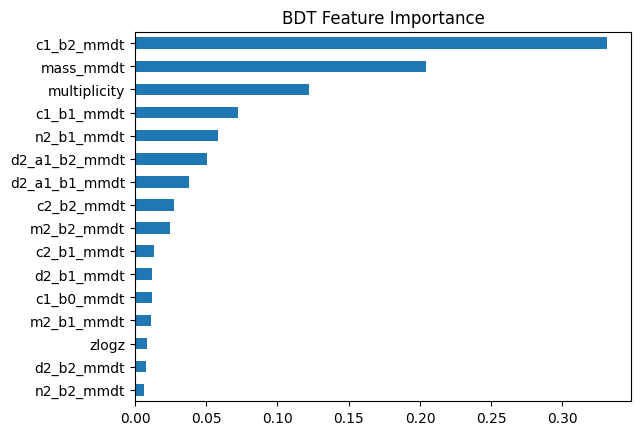

In [5]:
importances = pd.Series(xgb.feature_importances_, index=feature_names)
importances.sort_values().plot(kind='barh')
plt.title('BDT Feature Importance')
plt.show()

## 5. Prediction Distributions

For each event, the model predicts a probability for all five jet classes rather than a single binary score. This lets us inspect how confidently the network assigns events to each class.

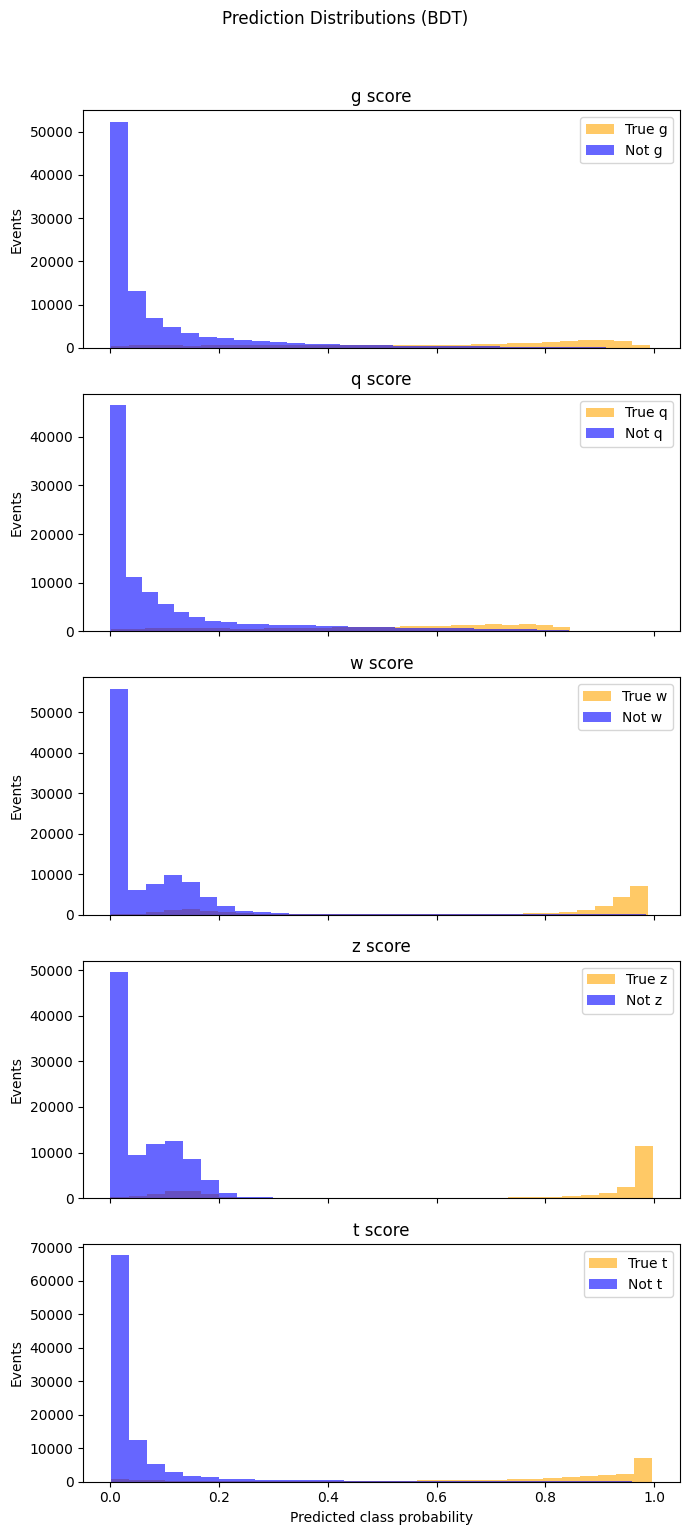

In [6]:
def plot_pred_distribution_multiclass(y_proba, y_true, class_names, bins=30):
    n_classes = len(class_names)

    fig, axes = plt.subplots(n_classes, 1, figsize=(7, 3 * n_classes), sharex=True)

    if n_classes == 1:
        axes = [axes]

    for i, ax in enumerate(axes):
        scores_i = y_proba[:, i]

        # true class i
        ax.hist(
            scores_i[y_true == i],
            bins=bins,
            alpha=0.6,
            label=f"True {class_names[i]}",
            color="orange",
            density=False
        )

        # all other classes
        ax.hist(
            scores_i[y_true != i],
            bins=bins,
            alpha=0.6,
            label=f"Not {class_names[i]}",
            color="blue",
            density=False
        )

        ax.set_ylabel("Events")
        ax.set_title(f"{class_names[i]} score")
        ax.legend()

    axes[-1].set_xlabel("Predicted class probability")
    fig.suptitle(f"Prediction Distributions (BDT)", y=1.02)
    plt.tight_layout()
    plt.show()

y_proba = xgb.predict_proba(X_test)
classes = ['g', 'q', 'w', 'z', 't']

plot_pred_distribution_multiclass(y_proba, y_test, classes)

## 6. ROC Curve Comparison

We again use ROC curves check whether the trained model is any good.

Accuracy xgboost:   0.75537


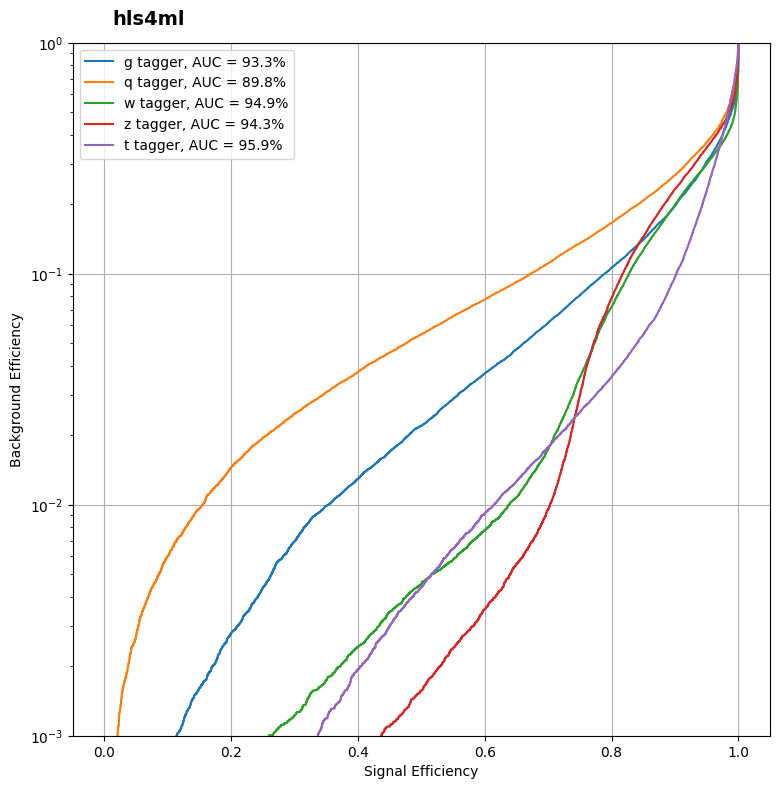

In [7]:
from sklearn.metrics import accuracy_score
repo_path = "/content/Scies4Free-FastML-tutorial"
sys.path.insert(0, repo_path)
import plotting

# compute predictions of the xgboost model
y_xgb = xgb.predict_proba(X_test)
# print(f'Accuracy baseline:  {accuracy_score(np.argmax(y_test_one_hot, axis=1), np.argmax(y_ref, axis=1)):.5f}')
print(f'Accuracy xgboost:   {accuracy_score(y_test, np.argmax(y_xgb, axis=1)):.5f}')

fig, ax = plt.subplots(figsize=(9, 9))
plt.gca().set_prop_cycle(None)  # reset the colors
# One-hot labels for ROC
ohe = OneHotEncoder(sparse_output=False)
y_test_one_hot = ohe.fit_transform(y_test.reshape(-1, 1))
_ = plotting.makeRoc(y_test_one_hot, y_xgb, classes, linestyle='-')

# add a legend
from matplotlib.lines import Line2D

lines = [
    Line2D([0], [0], ls='-'),
]
